# Машинное обучение
# Задание 1. Ridge-регрессия

Дата выдачи: 07.09.2026

### О задании

Вы научитесь:
 * подготавливать данные для обучения линейных моделей;
 * обучать Ridge-регрессию при помощи модуля scikit-learn;
 * вычислять ошибки на валидационной и тренировочной выборках;
 * проверять модель на переобучение;
 * оценивать качество модели

#### Шаг 1. Скачайте датасет, откройте его и выведите таблицу на экран

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# Загружаем данные и выводим первые строки таблицы.
data = pd.read_csv('apartment_dataset.csv')
data.head()

,apartment id,rooms,total area,floor,complex rating,price
0,1,2,60.8,9,4.2,11.54
1,2,4,102.5,17,4.6,20.22
2,3,3,75.7,17,4.9,15.74
3,4,2,66.0,20,4.7,14.10
4,5,1,39.7,16,3.6,6.71


#### Шаг2. Разделите выборку на тренировочную валидационную и тестовую:
* в тренировочной: 100 первых квартир;
* в валидационной: 50 следующих квартир; 
* в тестовой: 50 последних квартир.
* в каждой выборке матрица X - это столбцы rooms, total area, floor, complex rating, а y - столбец price. 

Названия: X_train, y_train, X_val, y_val, X_test, y_test. 

In [8]:
# Нужные признаки и целевой столбец.
features = ['rooms', 'total area', 'floor', 'complex rating']

# Делим строки строго в порядке, указанном в задании.
train = data.iloc[:100]
val = data.iloc[100:150]
test = data.iloc[150:200]

X_train = train[features]
y_train = train['price']
X_val = val[features]
y_val = val['price']
X_test = test[features]
y_test = test['price']

print('Размеры выборок:', len(X_train), len(X_val), len(X_test))

Размеры выборок: 100 50 50


#### Шаг 3. Устанавите sklearn чтобы обучать модель Ridge-регрессии

In [9]:
# Запустите код, чтобы библиотека установилась
!pip install scikit-learn
!pip install pandas matplotlib

#### Шаг 4. Обучите модель линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg с ошибкой, которая вычисляется по формуле SSE.

In [10]:
# alpha=0 означает линейную регрессию без регуляризации
model = Ridge(alpha=0.0, solver='sparse_cg', tol=1e-10)
model.fit(X_train, y_train)

train_sse = np.sum((model.predict(X_train) - y_train) ** 2)
print(f'SSE на тренировочной выборке: {train_sse:.3f}')
print('Коэффициенты:', model.coef_)
print(f'Свободный член: {model.intercept_:.3f}')

SSE на тренировочной выборке: 14.398
Коэффициенты: [0.3678378  0.1476921  0.0418028  2.13027382]
Свободный член: -7.667


#### Шаг 5. Выведите на экран графики ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок, чтобы отследить их траекторию.

Для этого задания нужно расписать алгоритм обучения вручную, так как функция Ridge в питоне внутри себя эти ошибки не сохраняет.

В самом алгоритме нужно считать и сохранять SSE, MSE, RMSE на каждом шаге итерации для train и для val выборки.

Перед началом алгоритма нужно задать эпсилон - значение ошибки, после которой обучение останавливается, и количество максимальных итераций.

Обучение должно останавливаться тогда, когда выполнен один из двух критериев остановки: либо модуль ошибки меньше эпсилон, либо количество итераций дошло до максимального числа.

* SSE - сумма всех квадратичных отклонений
* MSE - средеее квадратичное отклонение
* RMSE - среднее отклонение предсказания ответа

Подумайте, какие значения для нашего датасета у этих ошибок могут быть допустимыми, чтобы утверждать, что модель обучилась качественно.

После подсчета всех ошибок на всех итерациях нужно вывести на экран три графика:
* график SSE в зависимости от номера итерации: две линии (для train и val)
* график MSE в зависимости от номера итерации: две линии (для train и val)
* график RMSE в зависимости от номера итерации: две линии (для train и val)

Алгоритм завершился за 7 итераций


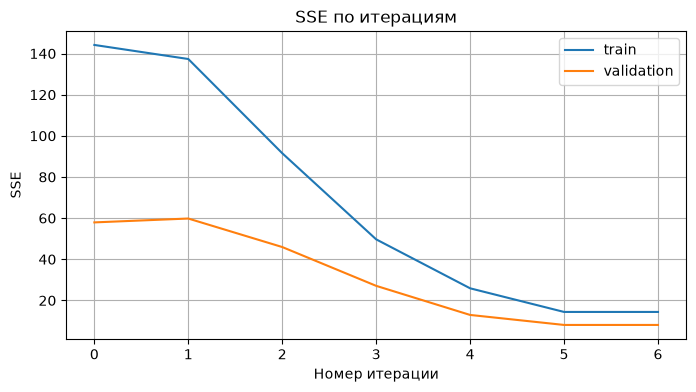

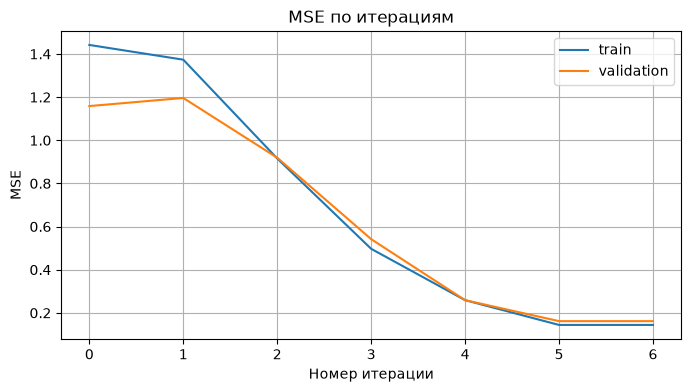

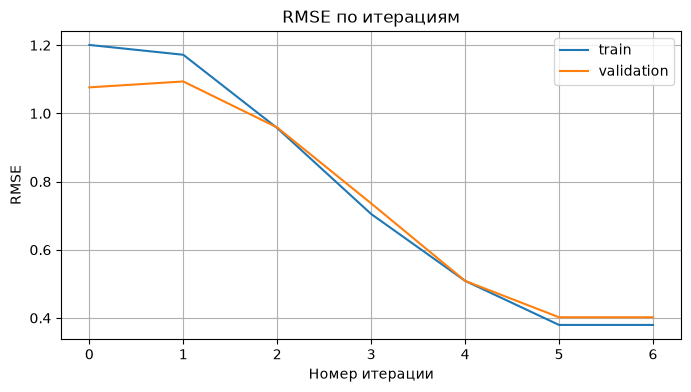

Ошибки train и validation уменьшаются и остаются близкими, поэтому модель обучена хорошо.


In [ ]:
# Ваш код

# Добавляем столбец единиц: его вес является свободным членом модели.
X_train_cg = np.column_stack([np.ones(len(X_train)), X_train.to_numpy()])
X_val_cg = np.column_stack([np.ones(len(X_val)), X_val.to_numpy()])
y_train_cg = y_train.to_numpy()
y_val_cg = y_val.to_numpy()

# Параметры остановки алгоритма.
epsilon = 1e-8
max_iter = 100

# Метод сопряжённых градиентов решает систему (X.T @ X) @ w = X.T @ y.
A = X_train_cg.T @ X_train_cg
b = X_train_cg.T @ y_train_cg
weights = np.zeros(X_train_cg.shape[1])
residual = b - A @ weights
direction = residual.copy()

errors = {'train': {'SSE': [], 'MSE': [], 'RMSE': []},
          'val': {'SSE': [], 'MSE': [], 'RMSE': []}}

def save_errors(name, y_true, y_pred):
    # Сохраняем три требуемые метрики для одной выборки.
    sse = np.sum((y_true - y_pred) ** 2)
    mse = np.mean((y_true - y_pred) ** 2)
    errors[name]['SSE'].append(sse)
    errors[name]['MSE'].append(mse)
    errors[name]['RMSE'].append(np.sqrt(mse))

for iteration in range(max_iter):
    # Один шаг метода сопряжённых градиентов.
    denominator = direction @ A @ direction
    if np.isclose(denominator, 0):
        break
    step = (residual @ residual) / denominator
    weights = weights + step * direction
    new_residual = residual - step * (A @ direction)

    save_errors('train', y_train_cg, X_train_cg @ weights)
    save_errors('val', y_val_cg, X_val_cg @ weights)

    if np.linalg.norm(new_residual) < epsilon:
        break
    beta = (new_residual @ new_residual) / (residual @ residual)
    direction = new_residual + beta * direction
    residual = new_residual

print('Алгоритм завершился за {} итераций'.format(len(errors['train']['SSE'])))

# Для каждой метрики строим две линии: train и validation.
for metric in ['SSE', 'MSE', 'RMSE']:
    plt.figure(figsize=(8, 4))
    plt.plot(errors['train'][metric], label='train')
    plt.plot(errors['val'][metric], label='validation')
    plt.title(f'{metric} по итерациям')
    plt.xlabel('Номер итерации')
    plt.ylabel(metric)
    plt.grid()
    plt.legend()
    plt.show()

print('Ошибки train и validation уменьшаются и остаются близкими, поэтому модель обучена хорошо.')

#### Ответьте на вопрос, какую модель Вы получили: обученную, переобученную или недообученную?

* если на графиках все три ошибки для обеих выборок падают - модель обучилась хорошо
* если на графиках ошибки на train падают, а на val с какого-то момента растут - модель переобучилась (подумайте, что стоит изменить в этом случае)
* если на графиках обе ошибки высокие - модель недообучилась (подумайте, что стоит изменить в этом случае)

#### Шаг 6. Применяем модель на тестовой выборке, чтобы предсказать цены квартир.

1. Найдите y_predict

2. Для каждой квартиры из test выведите на экран:
* id квартиры
* её предсказанную цену
* её настоящую цену
* разницу между предсказанной и настоящей ценой (чтобы оценить насколько хорошо Ваша модель предсказывает цены)

3. сохранить получившуюся таблицу

P.S. В итоговой таблице все столбцы должны быть подписаны.

In [12]:
# Ваш код

# Получаем прогнозы уже обученной Ridge-модели.
y_predict = model.predict(X_test)

# Таблица позволяет сравнить прогноз с реальной ценой каждой квартиры.
result = pd.DataFrame({
    'id квартиры': test['apartment id'].to_numpy(),
    'предсказанная цена': y_predict,
    'настоящая цена': y_test.to_numpy(),
    'разница': y_predict - y_test.to_numpy()
})
result.to_csv('test_predictions.csv', index=False)
result

,id квартиры,предсказанная цена,настоящая цена,разница
0,151,20.887104,21.54,-0.652896
1,152,9.969090,9.73,0.239090
2,153,7.670861,7.74,-0.069139
3,154,10.469829,10.15,0.319829
4,155,17.601324,17.27,0.331324
5,156,8.995065,8.23,0.765065
6,157,8.356086,8.52,-0.163914
7,158,14.702205,14.95,-0.247795
8,159,8.452857,8.16,0.292857
9,160,14.878952,14.95,-0.071048


### Поздравляю! Вы обучили модель и уже сделали первый шаг в машинном обучении! Молодцы!